<a href="https://colab.research.google.com/github/Biyush803/ai-ml_project/blob/main/Project_AI_ML-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploratory Data Analysis and Feature Engineering for Neural Network-Based Stock Price Direction Prediction**

Dataset Introduction

This project uses historical stock trading data for Agricultural Development Bank Limited (ADBL), a company listed on the Nepal Stock Exchange (NEPSE). The dataset contains daily trading records starting from September 2010 up to July 2026, giving almost sixteen years of continuous price history. Each row in the dataset represents one trading day and includes the date, the opening price, the highest and lowest price reached that day, the closing price, the percentage change from the previous day, and the number of shares traded (volume). This kind of data is commonly used in financial machine learning because it captures both price movement and market activity over time, which are the two main ingredients needed to predict whether a stock's price will go up or down the next day. ADBL was chosen over three other candidate companies because it had a long, mostly uninterrupted trading history and only minor data quality issues, unlike the other options which either had very little data, long trading gaps or more serious inconsistencies in their records.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.facecolor'] = 'white'

This cell simply loads the tools needed for the rest of the notebook. pandas is used to load and organize the data into a table format, numpy helps with numerical calculations, and matplotlib is used to draw charts and graphs.

In [3]:
df = pd.read_csv("ADBL.csv")
df['published_date'] = pd.to_datetime(df['published_date'])
df = df.sort_values('published_date').reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (3615, 9)


,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2010-09-16,117.0,122.0,116.0,120.0,NaN,5280.0,0.0,0
1,2010-09-19,120.0,120.0,116.0,118.0,-1.67,2648.0,0.0,0
2,2010-09-20,118.0,119.0,116.0,118.0,0.00,2346.0,0.0,0
3,2010-09-21,118.0,118.0,115.0,116.0,-1.69,7160.0,0.0,0
4,2010-09-23,116.0,120.0,117.0,120.0,3.45,8417.0,0.0,0


Since this notebook runs in Google Colab, which doesn't automatically have access to files on your computer, this cell opens a small upload button that lets you manually select and upload the ADBL.csv file so the notebook can read it.

Check missing values and duplicate dates

In [4]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate published_date rows:", df['published_date'].duplicated().sum())

Missing values per column:
published_date     0
open               0
high               0
low                0
close              0
per_change         1
traded_quantity    0
traded_amount      0
status             0
dtype: int64

Duplicate published_date rows: 15


Before working on any dataset, it's important to check if anything is broken or repeated. This cell checks whether any column has missing (empty) values and also checks whether any date appears more than once in the dataset, which shouldn't normally happen since each date should only have one trading record.

Inspect the duplicates

In [5]:
dupes = df[df.duplicated('published_date', keep=False)].sort_values('published_date')
dupes

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
66,2011-01-03,136.0,140.0,135.0,137.0,0.74,4292.0,0.0,0
67,2011-01-03,137.0,131.0,124.0,131.0,-4.38,4755.0,0.0,0
265,2011-11-29,160.0,163.0,155.0,156.0,0.00,2778.0,445990.0,0
266,2011-11-29,160.0,163.0,155.0,156.0,0.00,2778.0,445990.0,0
267,2011-11-29,160.0,163.0,155.0,156.0,32.20,2778.0,445990.0,0
464,2012-10-01,175.0,176.0,173.0,175.0,0.00,4962.0,869140.0,0
465,2012-10-01,175.0,176.0,173.0,175.0,0.00,4962.0,869140.0,0
791,2014-03-13,468.0,471.0,458.0,470.0,0.43,6624.0,3091316.0,0
792,2014-03-13,468.0,471.0,458.0,470.0,0.00,6624.0,3091316.0,0
829,2014-05-15,452.0,453.0,446.0,450.0,-0.44,1498.0,672591.0,0


Cleaning the Duplicate data

In [6]:
df_clean = df.drop_duplicates(subset='published_date', keep='last').reset_index(drop=True)

print("Before:", len(df), "rows")
print("After: ", len(df_clean), "rows")
print("Remaining duplicate dates:", df_clean['published_date'].duplicated().sum())

Before: 3615 rows
After:  3600 rows
Remaining duplicate dates: 0


After reviewing the duplicate rows, a decision was made to keep only the last recorded entry for each repeated date, since the most recently published version is assumed to be the corrected or finalized one. This cell removes the earlier duplicate entries and confirms that no duplicate dates remain afterward.

Check for large trading gaps

In [7]:
date_diffs = df_clean['published_date'].diff().dt.days.dropna()
print("Max gap between records:", date_diffs.max(), "days")
print("Number of gaps > 30 days:", (date_diffs > 30).sum())

Max gap between records: 51.0 days
Number of gaps > 30 days: 3


Stock markets aren't open every single day (weekends, holidays and sometimes trading halts), so small gaps between dates are normal. This cell measures the difference in days between each trading record and the one before it and flags any unusually large gaps, since a very long gap might indicate the stock was suspended from trading for a period of time.

Descriptive statistics

In [8]:
df_clean[['open','high','low','close','traded_quantity','traded_amount']].describe()


,open,high,low,close,traded_quantity,traded_amount
count,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3.600000e+03
mean,361.285208,366.202383,355.511806,361.089286,28069.918611,1.131763e+07
std,152.173013,154.830370,149.326228,152.454201,48240.830581,2.209539e+07
min,101.000000,103.000000,101.000000,101.000000,20.000000,0.000000e+00
25%,258.075000,262.175000,255.000000,258.000000,4674.000000,1.414855e+06
50%,344.000000,348.000000,340.000000,344.000000,13244.500000,4.828269e+06
75%,450.000000,455.000000,443.000000,450.000000,31505.500000,1.194892e+07
max,1082.000000,1113.000000,1048.000000,1082.000000,800592.000000,4.627646e+08


Closing price over time chart

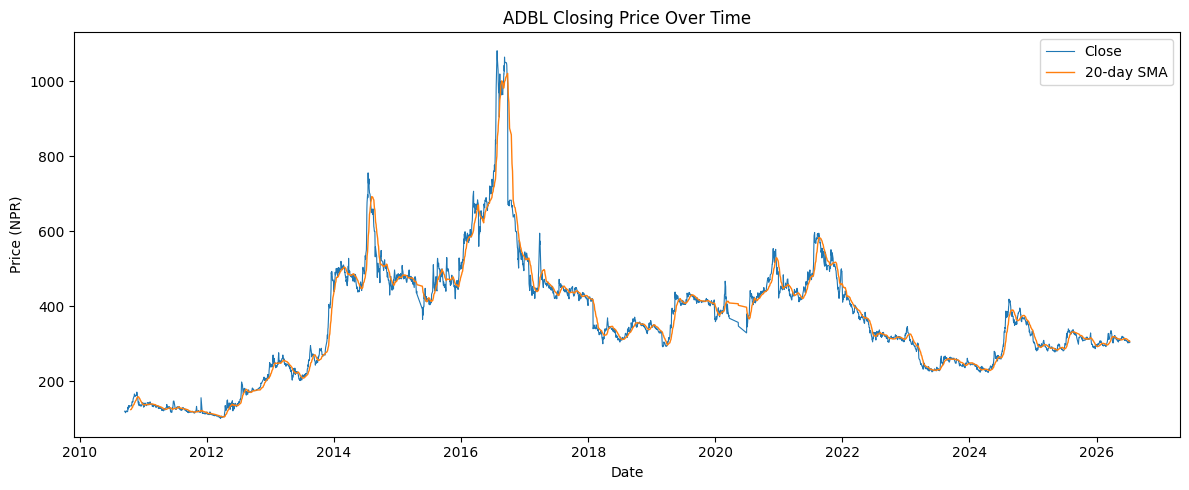

In [9]:
df_clean['sma_20_temp'] = df_clean['close'].rolling(20).mean()

plt.figure(figsize=(12,5))
plt.plot(df_clean['published_date'], df_clean['close'], label='Close', linewidth=0.8)
plt.plot(df_clean['published_date'], df_clean['sma_20_temp'], label='20-day SMA', linewidth=1)
plt.title('ADBL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (NPR)')
plt.legend()
plt.tight_layout()
plt.show()

df_clean.drop(columns=['sma_20_temp'], inplace=True)

This draws a line graph showing how the closing price has changed from 2010 to the present. Smoother line (the 20-day moving average) is added on top to make the overall trend easier to see, since raw daily prices can look noisy and jumpy on their own.

 Daily return distribution

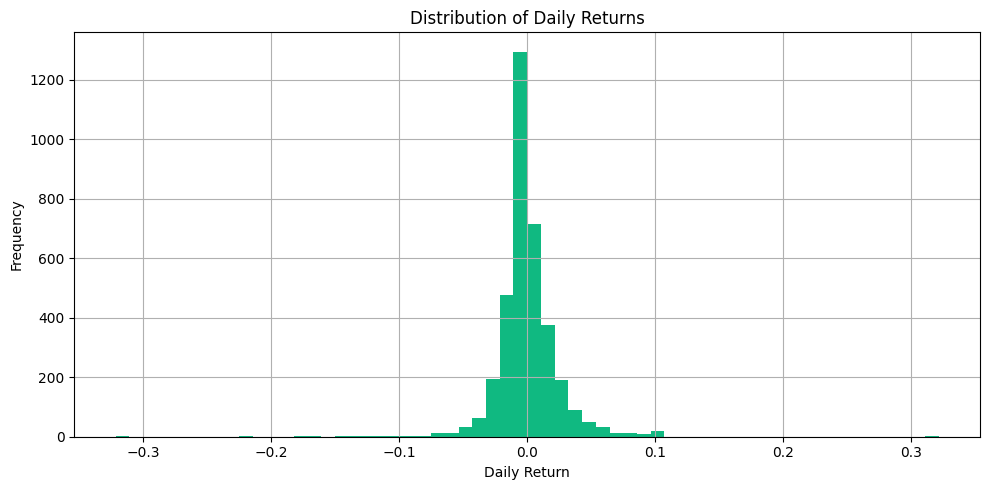

Return skewness: -0.054
Return kurtosis: 26.624


In [10]:
daily_return = df_clean['close'].pct_change()

plt.figure(figsize=(10,5))
daily_return.hist(bins=60, color='#10b981')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Return skewness:", daily_return.skew().round(3))
print("Return kurtosis:", daily_return.kurt().round(3))

Instead of looking at raw prices, this cell calculates the daily percentage change in price and draws a histogram. Most daily changes are expected to cluster tightly around zero, meaning prices don't move drastically on most days, but a few extreme days pull the tails of the chart outward.


Traded Volume over time

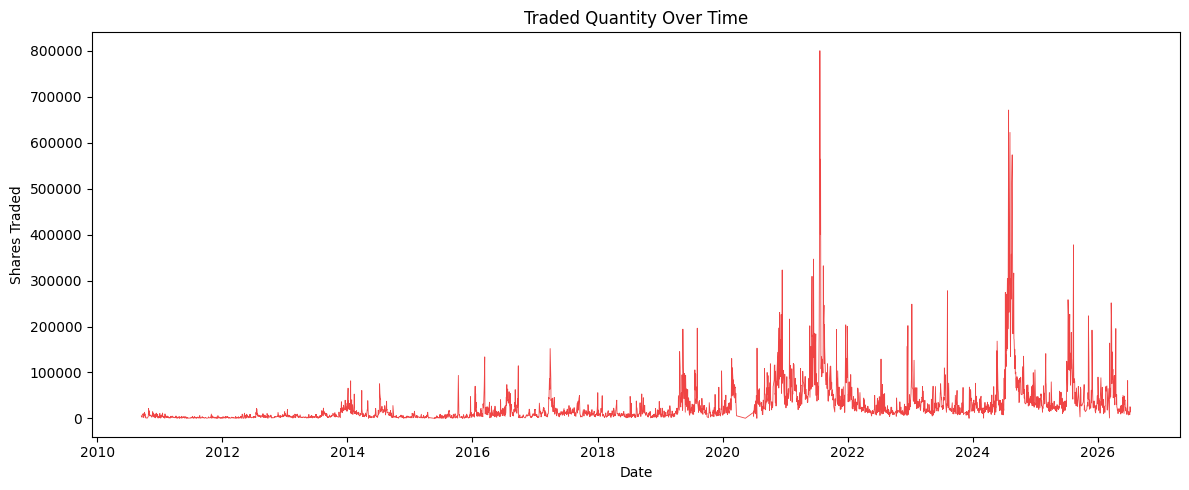

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df_clean['published_date'], df_clean['traded_quantity'], linewidth=0.6, color='#ef4444')
plt.title('Traded Quantity Over Time')
plt.xlabel('Date')
plt.ylabel('Shares Traded')
plt.tight_layout()
plt.show()

This plots the number of shares traded each day over time. Spikes in this chart usually correspond to unusually active trading days, which may line up with major news events or price swings.

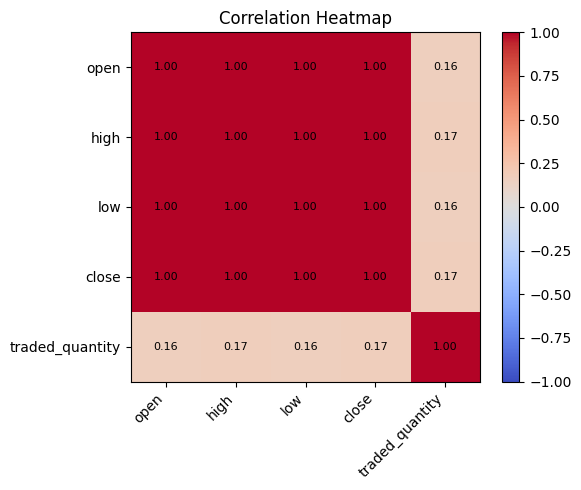

In [12]:
corr_cols = ['open','high','low','close','traded_quantity']
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(6,5))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, fraction=0.046)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

This cell checks how strongly different numeric columns relate to one another using a color-coded grid. Since open, high, low, and close prices are all recorded on the same trading day, they're expected to move almost identically together, which shows up as very high correlation. It also checks whether trading volume tends to rise or fall along with price, which turned out to be only weakly related.

Feature Engineering

In [13]:
df_feat = df_clean.copy()

# Daily return
df_feat['daily_return'] = df_feat['close'].pct_change()

# Lagged returns
for lag in [1, 2, 3]:
    df_feat[f'return_lag_{lag}'] = df_feat['daily_return'].shift(lag)

# Moving averages
df_feat['sma_5'] = df_feat['close'].rolling(5).mean()
df_feat['sma_10'] = df_feat['close'].rolling(10).mean()
df_feat['sma_20'] = df_feat['close'].rolling(20).mean()

# Rolling volatility
df_feat['volatility_10'] = df_feat['daily_return'].rolling(10).std()

# RSI (14-day)
delta = df_feat['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df_feat['rsi_14'] = 100 - (100 / (1 + rs))

# Volume change
df_feat['volume_change'] = df_feat['traded_quantity'].pct_change()

df_feat[['published_date','close','daily_return','sma_5','sma_10','sma_20',
         'volatility_10','rsi_14','volume_change']].tail(10)

,published_date,close,daily_return,sma_5,sma_10,sma_20,volatility_10,rsi_14,volume_change
3590,2026-06-29,304.7,-0.000984,306.18,307.42,310.485,0.002671,22.137405,-0.112558
3591,2026-06-30,302.0,-0.008861,305.08,306.72,309.745,0.003177,22.656250,1.015508
3592,2026-07-01,305.0,0.009934,304.54,306.38,309.125,0.005010,33.108108,-0.224581
3593,2026-07-02,306.8,0.005902,304.70,306.16,308.570,0.005417,40.606061,0.035262
3594,2026-07-03,307.0,0.000652,305.10,305.96,308.070,0.005430,37.179487,-0.125546
3595,2026-07-06,303.5,-0.011401,304.86,305.52,307.520,0.006382,33.918129,-0.192503
3596,2026-07-07,308.0,0.014827,306.06,305.57,307.320,0.008195,49.047619,2.069931
3597,2026-07-08,304.9,-0.010065,306.04,305.29,307.115,0.008807,41.276596,-0.036242
3598,2026-07-09,304.0,-0.002952,305.48,305.09,306.815,0.008693,39.754098,-0.429215
3599,2026-07-10,303.2,-0.002632,304.72,304.91,306.480,0.008673,40.248963,0.273288


This is where new, more useful columns are created from the raw price data to help a future model detect patterns. This includes past daily returns (how much the price changed on previous days), moving averages over different time windows, a measure of how volatile or "jumpy" the price has recently been, the Relative Strength Index (RSI, a common indicator showing whether a stock might be overbought or oversold), and the percentage change in trading volume. These engineered features turn simple raw prices into signals that are more directly useful for a neural network to learn from later.

Link to Github: